<a href="https://colab.research.google.com/github/Maks04092002/IS484-Lab001-Jueves-Tanta/blob/main/Ejercicio1_Credito_Apellido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

| Componente | Descripción |
| :--- | :--- |
| **Percepción (S)** | `ingreso_mensual` (S/), `monto_solicitado` (S/), `tiene_historial_moroso` (booleano). |
| **Acciones (A)** | Aprobar, aprobar con condiciones, rechazar. |
| **Entorno (E)** | Sistema core de evaluación crediticia bancaria. |
| **Objetivo** | Maximizar la colocación de créditos seguros minimizando la tasa de impago. |
| **Medida de desempeño (P)** | Porcentaje de créditos cobrados a tiempo frente al nivel de morosidad registrado. |

### Justificación de las reglas
Las reglas se diseñaron para proteger la liquidez del banco:
Contar con historial moroso es un descarte inmediato por riesgo directo de impago.
Una relación monto/ingreso mayor a 0.50 indica sobreendeudamiento crítico, mientras que un nivel entre 0.30 y 0.50 exige condiciones adicionales (como avales o garantías) para mitigar el riesgo.
Niveles menores o iguales a 0.30 sin historial moroso son financieramente sostenibles.

In [4]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso:
        return ("rechazar", "El cliente registra historial moroso en el sistema.")
    elif relacion > 0.5:
        return ("rechazar", f"Relación monto/ingreso muy alta ({relacion:.2f} > 0.50). Riesgo de sobreendeudamiento.")
    elif relacion > 0.3:
        return ("aprobar con condiciones", f"Relación monto/ingreso moderada ({relacion:.2f}). Requiere aval o garantía.")
    else:
        return ("aprobar", f"Relación monto/ingreso óptima ({relacion:.2f}) e historial crediticio limpio.")

In [5]:
# Lista de 6 casos de prueba (incluyendo valores límite en 0.30 y 0.50)
casos_prueba = [
    (5000, 1000, False),  # Relación 0.20 -> Aprobar
    (5000, 1500, False),  # Relación 0.30 (Límite inferior) -> Aprobar
    (5000, 2000, False),  # Relación 0.40 -> Aprobar con condiciones
    (5000, 2500, False),  # Relación 0.50 (Límite superior) -> Aprobar con condiciones
    (5000, 3000, False),  # Relación 0.60 -> Rechazar
    (5000, 1000, True),   # Relación 0.20 pero con Historial Moroso -> Rechazar
]

print("--- RESULTADOS DE LA SIMULACIÓN DE CRÉDITO ---")
for ingreso, monto, moroso in casos_prueba:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"Ingreso: S/{ingreso} | Monto: S/{monto} | Moroso: {moroso} => [{accion.upper()}] - {motivo}")

--- RESULTADOS DE LA SIMULACIÓN DE CRÉDITO ---
Ingreso: S/5000 | Monto: S/1000 | Moroso: False => [APROBAR] - Relación monto/ingreso óptima (0.20) e historial crediticio limpio.
Ingreso: S/5000 | Monto: S/1500 | Moroso: False => [APROBAR] - Relación monto/ingreso óptima (0.30) e historial crediticio limpio.
Ingreso: S/5000 | Monto: S/2000 | Moroso: False => [APROBAR CON CONDICIONES] - Relación monto/ingreso moderada (0.40). Requiere aval o garantía.
Ingreso: S/5000 | Monto: S/2500 | Moroso: False => [APROBAR CON CONDICIONES] - Relación monto/ingreso moderada (0.50). Requiere aval o garantía.
Ingreso: S/5000 | Monto: S/3000 | Moroso: False => [RECHAZAR] - Relación monto/ingreso muy alta (0.60 > 0.50). Riesgo de sobreendeudamiento.
Ingreso: S/5000 | Monto: S/1000 | Moroso: True => [RECHAZAR] - El cliente registra historial moroso en el sistema.


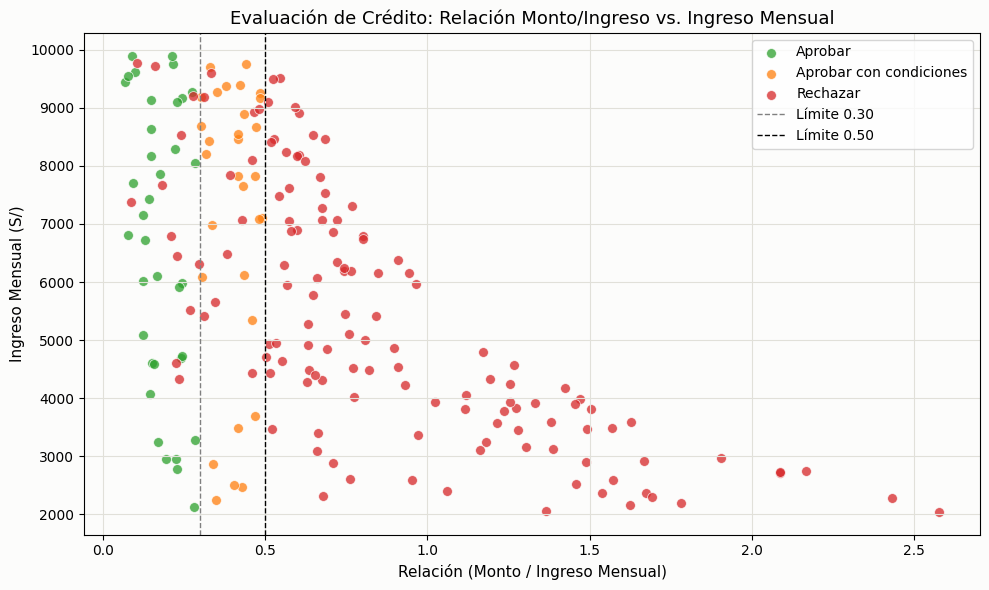

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

# Generación aleatoria de datos
ingresos = np.random.uniform(2000, 10000, n)
montos = np.random.uniform(500, 6000, n)
morosos = np.random.choice([True, False], size=n, p=[0.2, 0.8])

decisiones = []
relaciones = []

for i in range(n):
    accion, _ = agente_credito(ingresos[i], montos[i], morosos[i])
    decisiones.append(accion)
    relaciones.append(montos[i] / ingresos[i])

colores = {
    "aprobar": "#2ca02c",                  # Verde
    "aprobar con condiciones": "#ff7f0e",  # Naranja
    "rechazar": "#d62728"                  # Rojo
}

plt.figure(figsize=(10, 6), facecolor="#fcfcfb")
ax = plt.axes()
ax.set_facecolor("#fcfcfb")

for dec in ["aprobar", "aprobar con condiciones", "rechazar"]:
    idx = [j for j, d in enumerate(decisiones) if d == dec]
    ax.scatter(
        [relaciones[j] for j in idx],
        [ingresos[j] for j in idx],
        c=colores[dec],
        label=dec.capitalize(),
        alpha=0.75,
        edgecolors="white",
        linewidths=0.6,
        s=50
    )

plt.axvline(x=0.3, color="gray", linestyle="--", linewidth=1, label="Límite 0.30")
plt.axvline(x=0.5, color="black", linestyle="--", linewidth=1, label="Límite 0.50")

plt.title("Evaluación de Crédito: Relación Monto/Ingreso vs. Ingreso Mensual", fontsize=13)
plt.xlabel("Relación (Monto / Ingreso Mensual)", fontsize=11)
plt.ylabel("Ingreso Mensual (S/)", fontsize=11)
plt.legend(loc="upper right")
plt.grid(True, color="#e1e0d9", linewidth=0.8)
plt.tight_layout()
plt.show()